Здесь познакомлюсь с задачей

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
import kagglehub
import os

data_path = kagglehub.competition_download('playground-series-s6e1')

100%|██████████| 13.8M/13.8M [00:00<00:00, 138MB/s]

Extracting files...


# Основной код

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, cv, Pool
np.random.seed(42)
train_data = pd.read_csv(data_path + '/train.csv')
test_data = pd.read_csv(data_path + '/test.csv')

In [ ]:
num_features = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
cat_features = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

train_pool = Pool(train_data[num_features + cat_features], train_data['exam_score'], cat_features=cat_features)
params = {
    'iterations': None,
    'loss_function': 'RMSE',
    'verbose': False,
    'task_type': 'GPU'
}
cv_results = cv(
    pool=train_pool,
    params=params,
    fold_count=5,
    partition_random_seed=42,
    early_stopping_rounds=20,
    shuffle=True,
    logging_level='Verbose'
)


In [ ]:
cv_results.tail()

,iterations,test-RMSE-mean,test-RMSE-std,train-RMSE-mean,train-RMSE-std
995,995,8.829019,0.014883,8.81924,0.004584
996,996,8.829019,0.014883,8.81924,0.004584
997,997,8.829019,0.014883,8.81924,0.004584
998,998,8.829019,0.014883,8.81924,0.004584
999,999,8.829019,0.014883,8.81924,0.004584


## Финальное обучение и сабмит

In [ ]:
best_iteration = cv_results.loc[cv_results['train-RMSE-mean'].idxmin(), 'iterations']
params['iterations']= best_iteration
params['verbose'] = int(best_iteration // 10)
final_model = CatBoostRegressor(**params)
final_model.fit(train_pool)

Learning rate set to 0.094034
0:	learn: 17.7628541	total: 61.2ms	remaining: 1m 1s
99:	learn: 8.8287460	total: 6.54s	remaining: 58.8s
198:	learn: 8.8061613	total: 11.7s	remaining: 46.9s
297:	learn: 8.7913088	total: 17s	remaining: 39.9s
396:	learn: 8.7798033	total: 21.6s	remaining: 32.7s
495:	learn: 8.7700660	total: 27s	remaining: 27.4s
594:	learn: 8.7611357	total: 35s	remaining: 23.8s
693:	learn: 8.7531125	total: 42.4s	remaining: 18.6s
792:	learn: 8.7458213	total: 47.8s	remaining: 12.4s
891:	learn: 8.7389865	total: 54.7s	remaining: 6.56s
990:	learn: 8.7324656	total: 1m 1s	remaining: 493ms
998:	learn: 8.7319301	total: 1m 1s	remaining: 0us


In [ ]:
test_pool = Pool(test_data[num_features+cat_features], cat_features=cat_features)
y_pred = final_model.predict(test_pool)
submission = pd.DataFrame({
    'id': test_data['id'],
    'exam_score': y_pred,
})
submission.to_csv('submission.csv', index=False)

In [ ]:
submission.head()

,id,exam_score
0,630000,71.504589
1,630001,70.394589
2,630002,88.203459
3,630003,56.482677
4,630004,46.952191


In [ ]:
!kaggle competitions submit -c playground-series-s6e1 -f submission.csv -m "Message"

100% 6.45M/6.45M [00:02<00:00, 2.66MB/s]
Successfully submitted to Predicting Student Test Scores

## Важность признаков

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_data[num_features + cat_features], train_data['exam_score'],
    test_size=0.2, random_state=33, shuffle=True)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

model = CatBoostRegressor(**params)
model.fit(train_pool)

Learning rate set to 0.091325
0:	learn: 17.8090106	total: 51.1ms	remaining: 51s
99:	learn: 8.8327542	total: 5.37s	remaining: 48.3s
198:	learn: 8.8094268	total: 9.12s	remaining: 36.7s
297:	learn: 8.7942360	total: 13s	remaining: 30.5s
396:	learn: 8.7815260	total: 17.5s	remaining: 26.5s
495:	learn: 8.7710789	total: 21.2s	remaining: 21.5s
594:	learn: 8.7617590	total: 25.1s	remaining: 17s
693:	learn: 8.7531718	total: 29.7s	remaining: 13s
792:	learn: 8.7448302	total: 33.4s	remaining: 8.68s
891:	learn: 8.7368691	total: 37.4s	remaining: 4.48s
990:	learn: 8.7294552	total: 41.7s	remaining: 337ms
998:	learn: 8.7289938	total: 42s	remaining: 0us


### Feature importance

In [ ]:
pd.DataFrame({
    'cols': train_pool.get_feature_names(),
    'importances': model.get_feature_importance()
}).sort_values('importances', ascending=False)

,cols,importances
1,study_hours,48.213126
2,class_attendance,20.996164
7,sleep_quality,10.243983
8,study_method,8.650891
9,facility_rating,6.679204
3,sleep_hours,4.649912
0,age,0.217746
5,course,0.152412
4,gender,0.096583
10,exam_difficulty,0.055420


### Permutation

In [ ]:
fi = model.get_feature_importance(
    data=val_pool,
    type='LossFunctionChange',
)
pd.DataFrame({
    'feature': val_pool.get_feature_names(),
    'importance': fi
}).sort_values('importance', ascending=False)

,feature,importance
1,study_hours,7.302903
2,class_attendance,1.643439
7,sleep_quality,0.768865
8,study_method,0.634798
9,facility_rating,0.510654
3,sleep_hours,0.324486
5,course,0.001034
0,age,0.000586
4,gender,0.000411
6,internet_access,-0.000104


### Shap

In [ ]:
shap_vals = model.get_feature_importance(
    data=val_pool,
    type='ShapValues'
)

In [ ]:
shap = shap_vals[:, :-1]
global_importance = np.mean(np.abs(shap), axis=0)
pd.DataFrame({
    'feature': val_pool.get_feature_names(),
    'importance': global_importance
}).sort_values('importance', ascending=False)

,feature,importance
1,study_hours,11.661322
2,class_attendance,4.768997
7,sleep_quality,3.180043
8,study_method,3.022658
9,facility_rating,2.496241
3,sleep_hours,2.095798
0,age,0.137923
4,gender,0.125622
5,course,0.112565
10,exam_difficulty,0.055339


# Выводы и гипотезы

1. y - не нормальное распределение - немного не тянет
2. про study_hours можно помочь признаками типа мало учит и много, но пока без этого
3. тоже самое про class_attendance
4. Некоторые катфичи можно сделать дискретными числовыми где явный порядок типа рейтинга, сложности, качества сна и тп

5. age хоть и не особо важен, но и не вредит - можно оставить пусть будет
6. Сделать cat_features порядковыми: course (полагается градация курсов от младшего к старшему), exam_dificulity, sleep_quality (да, он хоть и по важности норм, но я думаю, что модель должна его адекватнее воспринимать).
7. Удалю gender, ибо он по всем feature importance лажа (точнее если он и после пункта 6 будет лажой), ну и по сути - гендер не влияет на успеваемость будь ты male female или даже other...
8. internet_access можно не убирать пока что, потому что возможно модель его не очень воспринимает из-за плохих других фич

# Поток

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
import scipy.stats as stats
from sklearn.model_selection import train_test_split

In [ ]:
train_data.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

<Axes: xlabel='course', ylabel='count'>

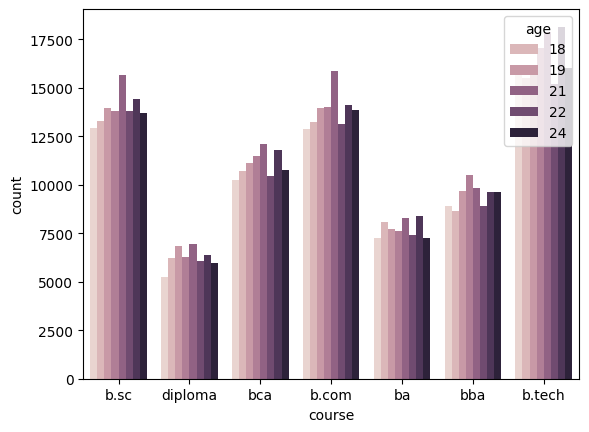

In [ ]:
sns.countplot(x='course', hue='age', data=train_data)

<Axes: >

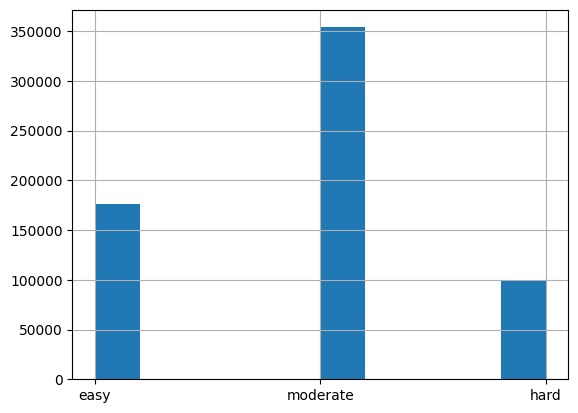

In [ ]:
train_data['exam_difficulty'].hist()

<Axes: >

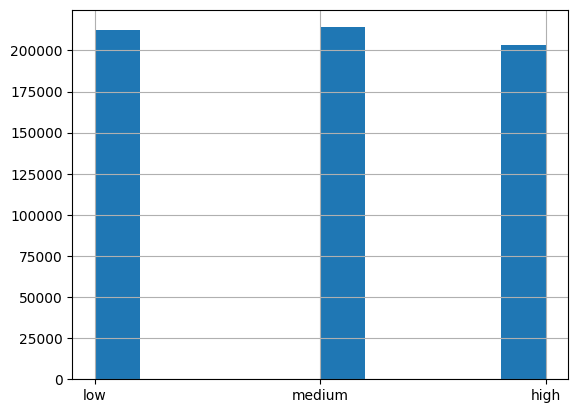

In [ ]:
train_data['facility_rating'].hist()

<Axes: >

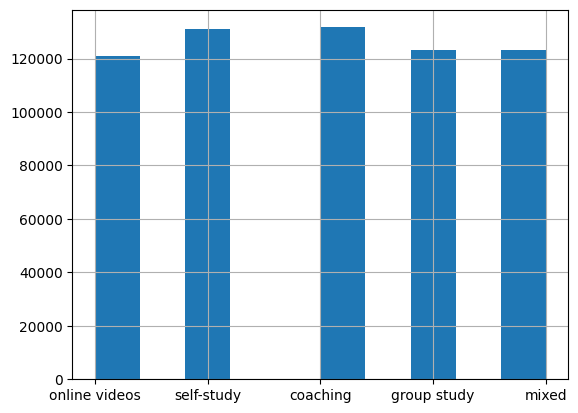

In [ ]:
train_data['study_method'].hist()

<Axes: >

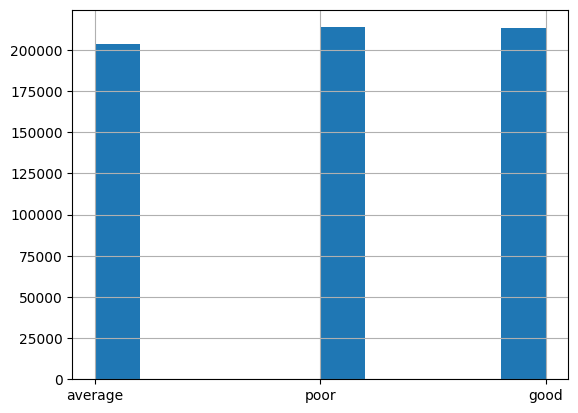

In [ ]:
train_data['sleep_quality'].hist()

<Axes: xlabel='sleep_hours', ylabel='Count'>

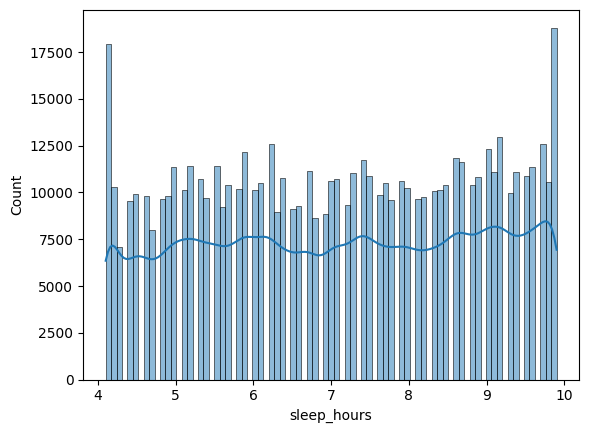

In [ ]:
sns.histplot(train_data['sleep_hours'], kde=True)

<Axes: >

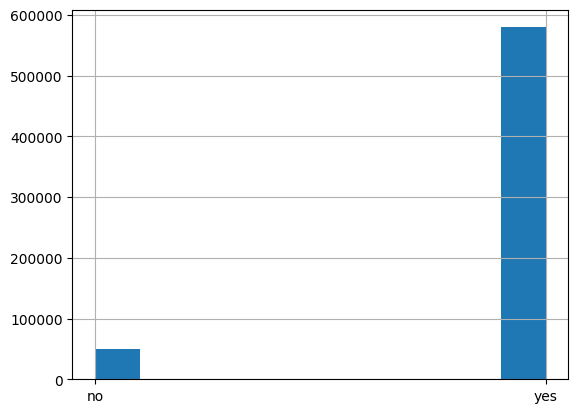

In [ ]:
train_data['internet_access'].hist()

<Axes: xlabel='class_attendance', ylabel='Count'>

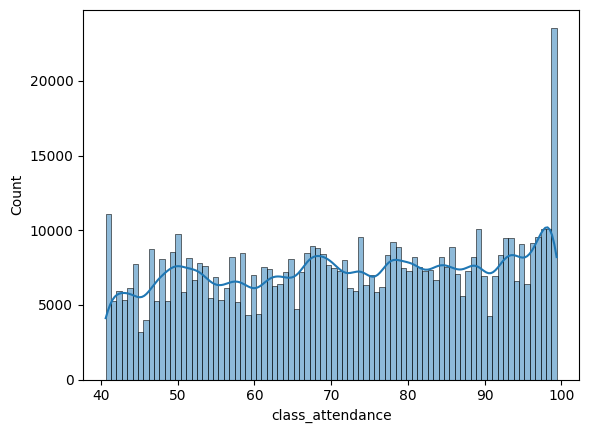

In [ ]:
sns.histplot(train_data['class_attendance'], kde=True)

<Axes: xlabel='study_hours', ylabel='Count'>

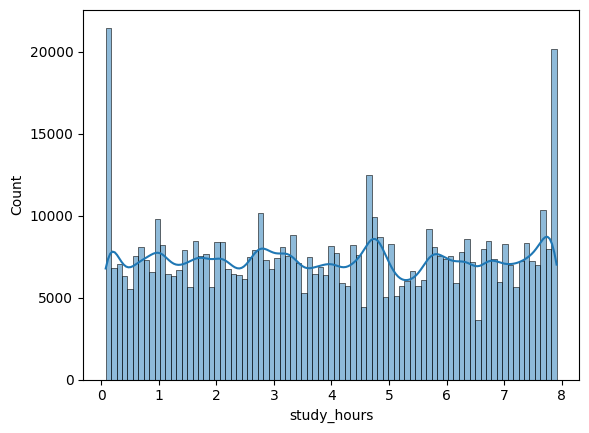

In [ ]:
sns.histplot(train_data['study_hours'], kde=True)

<Axes: >

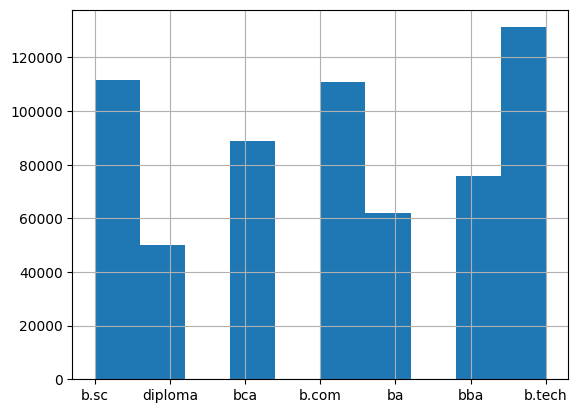

In [ ]:
train_data['course'].hist()

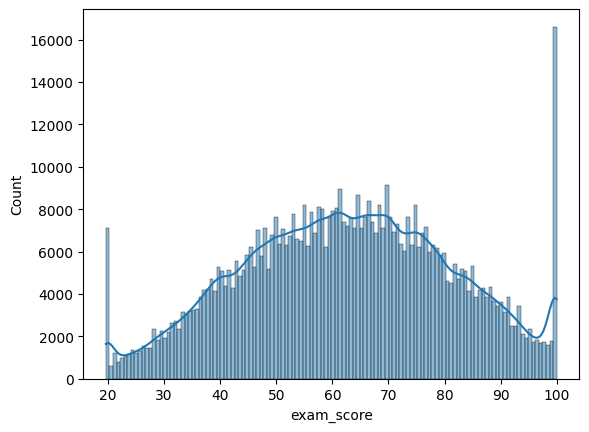

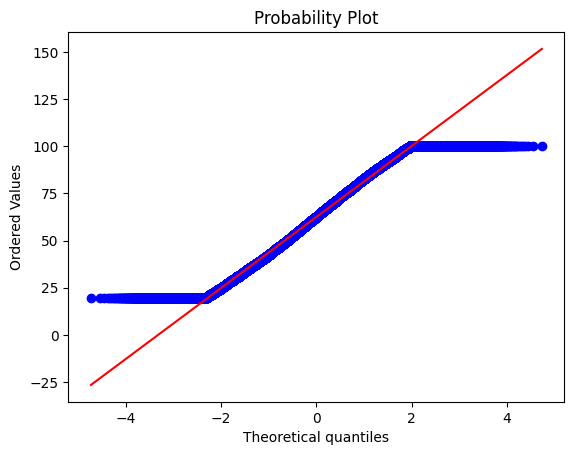

In [ ]:
sns.histplot(train_data['exam_score'], kde=True)
plt.show()

stats.probplot(train_data['exam_score'], dist='norm', plot=plt)
plt.show()

In [ ]:
train_data.isnull().sum()

,0
id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [ ]:
test_data.isnull().sum()

,0
id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


<Axes: xlabel='gender', ylabel='exam_score'>

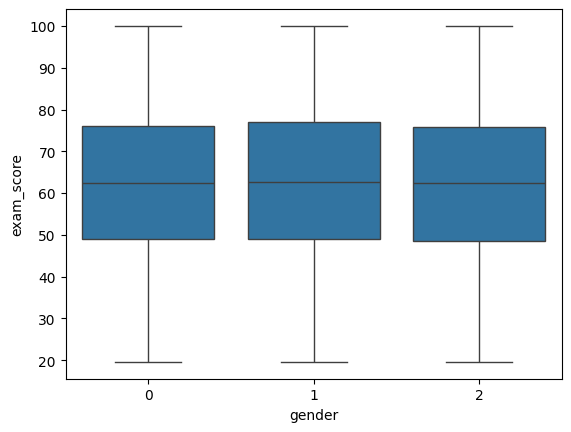

In [ ]:
gender = train_data['gender'].map({'female': 0, 'other': 1, 'male': 2})
sns.boxplot(x=gender, y=train_data['exam_score'])

In [ ]:
train_data.groupby('gender')['exam_score'].mean()

,exam_score
gender,
female,62.563220
male,62.175561
other,62.781191


<Axes: ylabel='exam_score'>

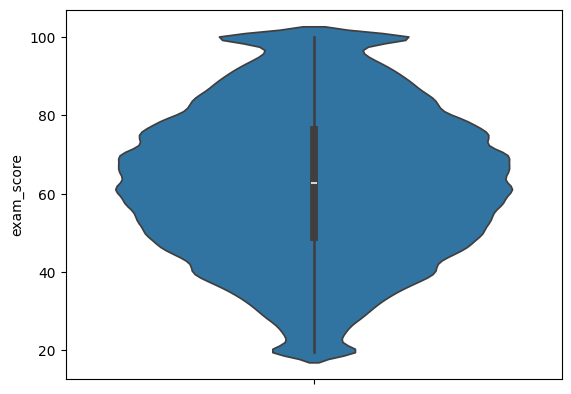

In [ ]:
sns.violinplot(train_data['exam_score'])

<Axes: ylabel='exam_score'>

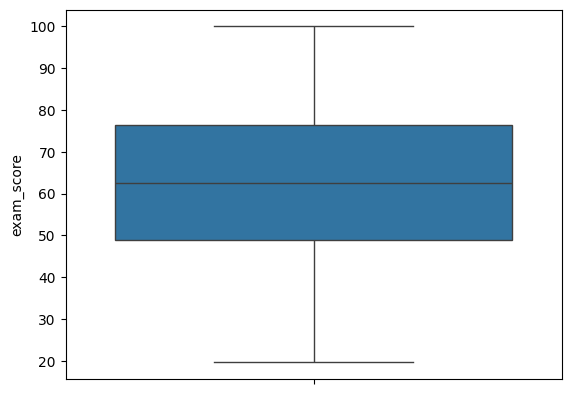

In [ ]:
sns.boxplot(train_data['exam_score'])

In [ ]:
from scipy.stats import kstest, norm
y = train_data['exam_score']
stat, p = kstest((y - y.mean()) / y.std(), 'norm')
if p > 0.05:
    print('Нормальное распределение')
else:
    print('Не нормальное')

Не нормальное


<Axes: xlabel='exam_score', ylabel='Density'>

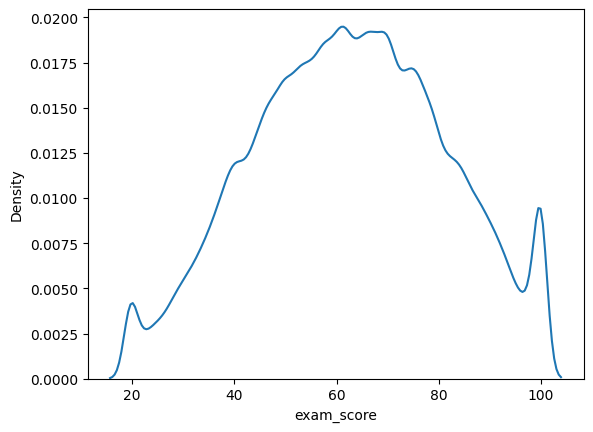

In [ ]:
sns.kdeplot(train_data['exam_score'])

<Axes: >

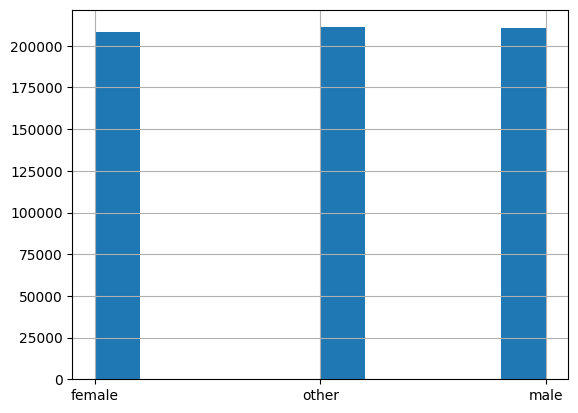

In [ ]:
train_data['gender'].hist()

Какие мы толерантные

In [ ]:
train_data['age'].unique()

array([21, 18, 20, 19, 23, 24, 22, 17])

<Axes: xlabel='age', ylabel='Density'>

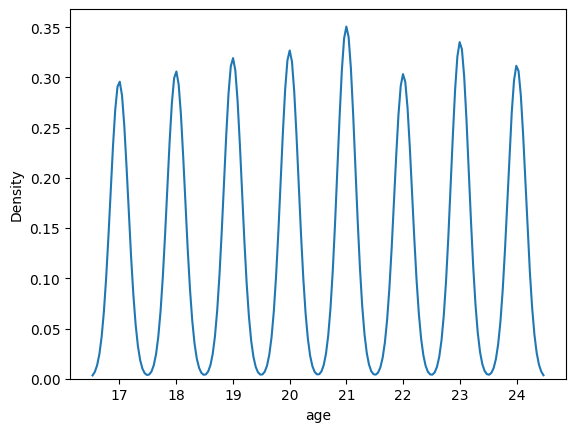

In [ ]:
sns.kdeplot(train_data, x='age')

In [ ]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


#